In [1]:
from asmcmc.base.initialize import RandomLatticeInitializer, ColumnarLatticeInitializer, FrameInitializer
from asmcmc.base.metropolis import MetropolisCalculator
from asmcmc.base.potentials import GBQPotential, CACELLI_POTENTIAL
from asmcmc.utils.measurements import (
    TrajectoryAnalyzer, 
    RadialDistributionFunction, 
    OrientationalCorrelationFunction, 
    HeatCapacity, 
    NematicOrderParameter, 
    AverageEnthalpy,
    BOLTZCONST
)

import pickle
import os
import json

import matplotlib.pyplot as plt
import numpy as np

from ase.db import connect
import ase.io

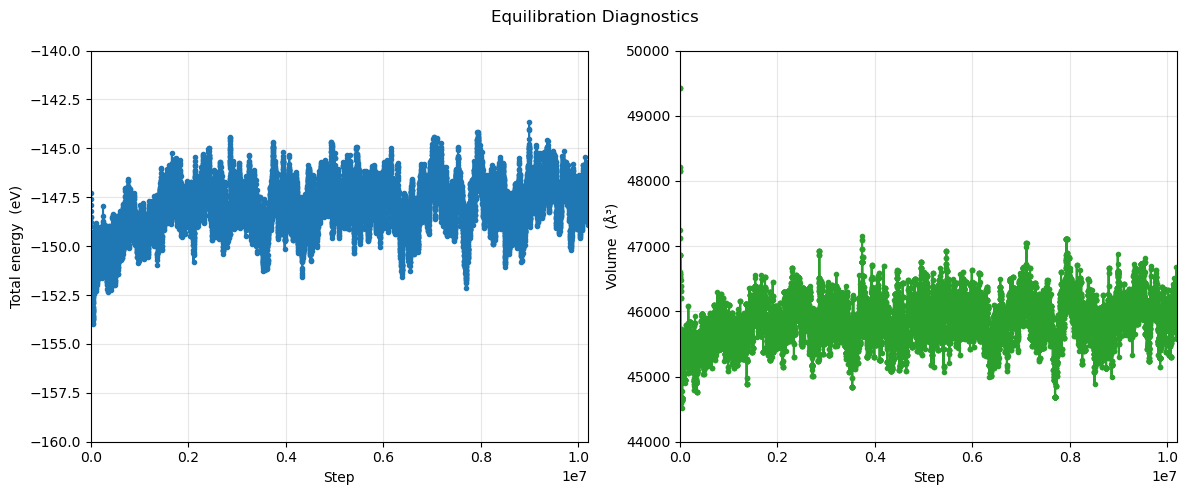

In [2]:
# Equilibration Diagnostics

steps, energy, vol = [], [], []
with connect("/home/lucas/Projects/cersonsky/asmcmc/results/validation/300.0_6.324209e-07/herringbone_jittered_0/equilibration.db") as db:
    for row in db.select():
        steps.append(row.step)
        energy.append(row.total_energy)
        vol.append(row.vol)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

MIN_STEP = 0
MAX_STEP = max(steps)

MIN_ENERGY = -160
MAX_ENERGY = -140

MIN_VOL = 44_000
MAX_VOL = 50_000


def fit_line(ax, x, y, xlim, ylim):
    """Fit a line to the points inside the (xlim, ylim) window and draw it.

    Masking against the same bounds used for the axes means the fit
    follows the plot window: change MIN_*/MAX_* and the line updates.
    """
    x, y = np.asarray(x), np.asarray(y)
    (xlo, xhi), (ylo, yhi) = xlim, ylim
    mask = (x >= xlo) & (x <= xhi) & (y >= ylo) & (y <= yhi)
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    xs = np.array([xlo, xhi])
    ax.plot(xs, slope * xs + intercept, color="black", ls="--",
            label=f"fit: {slope:.3g}·step + {intercept:.3g}")
    ax.legend()


axs[0].plot(steps, energy, marker=".")
axs[0].set_ylabel("Total energy  (eV)")
#fit_line(axs[0], steps, energy, (MIN_STEP, MAX_STEP), (MIN_ENERGY, MAX_ENERGY))

axs[1].plot(steps, vol, marker=".", color="tab:green")
axs[1].set_ylabel("Volume  (Å³)")
#fit_line(axs[1], steps, vol, (MIN_STEP, MAX_STEP), (MIN_VOL, MAX_VOL))

for ax in axs:
    ax.set_xlabel("Step")
    ax.grid(True, alpha=0.3)

axs[0].set_xbound(MIN_STEP, max(steps))
axs[1].set_xbound(MIN_STEP, max(steps))

axs[0].set_ybound(MIN_ENERGY, MAX_ENERGY)
axs[1].set_ybound(MIN_VOL, MAX_VOL)


fig.suptitle("Equilibration Diagnostics")
fig.tight_layout()

fig.savefig("../results/validation/300.0_6.324209e-07/herringbone_jittered_0/equilibration_diagnostics.png", dpi=150)

plt.show()

In [3]:
# Write equilibration to .xyz file so that it can be visualized
# To perform the write, set WRITE_TO_XYZ = True

WRITE_TO_XYZ = False

if WRITE_TO_XYZ:
    eq_traj = []

    with connect("../results/validation/300.0_6.324209e-07/herringbone_jittered_0/equilibration.db") as db:
        for row in db.select():
            atoms = row.toatoms()
            atoms.new_array("c_q", np.asarray(row.data["c_q"]))
            atoms.new_array("or_vec", np.asarray(row.data["or_vec"]))
            atoms.new_array("shape", np.asarray([[2.5, 2.5, 1.0] for _ in atoms]))
            atoms.info["total_energy"] = row["total_energy"]

            eq_traj.append(atoms)

    ase.io.write("../results/validation/300.0_6.324209e-07/herringbone_jittered_0/equilibration.xyz", eq_traj, format="extxyz")

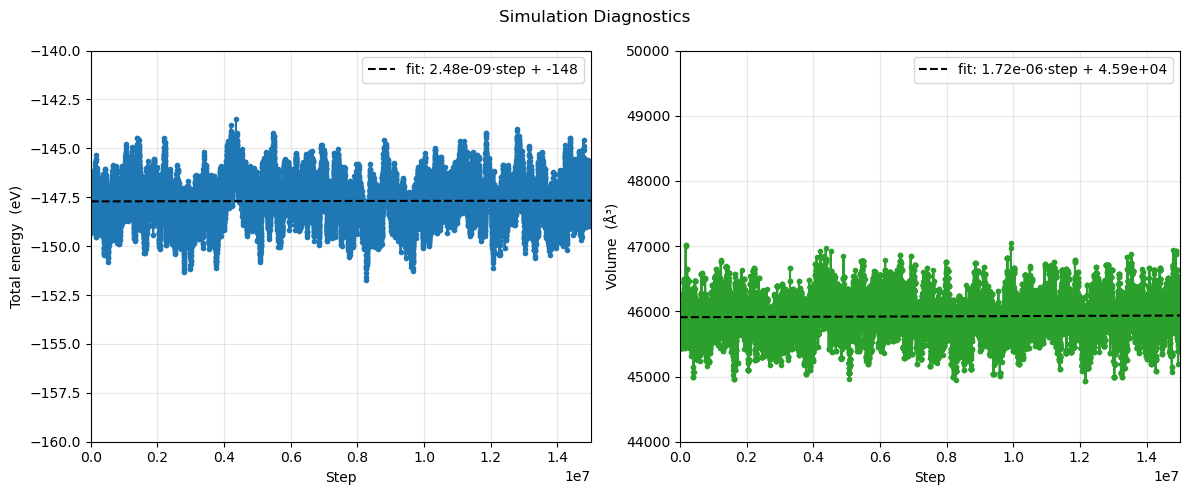

In [4]:
# Basic simulation diagnostics

steps, energy, vol = [], [], []
with connect("../results/validation/300.0_6.324209e-07/herringbone_jittered_0/simulation.db") as db:
    for row in db.select():
        steps.append(row.step)
        energy.append(row.total_energy)
        vol.append(row.vol)


fig, axs = plt.subplots(1, 2, figsize=(12, 5))
MAX_STEP = max(steps)


axs[0].plot(steps, energy, marker=".")
axs[0].set_ylabel("Total energy  (eV)")
fit_line(axs[0], steps, energy, (MIN_STEP, MAX_STEP), (MIN_ENERGY, MAX_ENERGY))

axs[1].plot(steps, vol, marker=".", color="tab:green")
axs[1].set_ylabel("Volume  (Å³)")
fit_line(axs[1], steps, vol, (MIN_STEP, MAX_STEP), (MIN_VOL, MAX_VOL))

for ax in axs:
    ax.set_xlabel("Step")
    ax.grid(True, alpha=0.3)

axs[0].set_xbound(MIN_STEP, max(steps))
axs[1].set_xbound(MIN_STEP, max(steps))

axs[0].set_ybound(MIN_ENERGY, MAX_ENERGY)
axs[1].set_ybound(MIN_VOL, MAX_VOL)


fig.suptitle("Simulation Diagnostics")
fig.tight_layout()

fig.savefig("../results/validation/300.0_6.324209e-07/herringbone_jittered_0/simulation_diagnostics.png", dpi=150)

plt.show()

In [ ]:
# Write simulation to .xyz file so that it can be visualized
# To perform the write, set WRITE_TO_XYZ = True

WRITE_TO_XYZ = False

if WRITE_TO_XYZ:
    traj = []

    with connect("../results/validation/100.0_6.324209e-07/herringbone_jittered/simulation.db") as db:
        for row in db.select():
            atoms = row.toatoms()
            atoms.new_array("c_q", np.asarray(row.data["c_q"]))
            atoms.new_array("or_vec", np.asarray(row.data["or_vec"]))
            atoms.new_array("shape", np.asarray([[2.5, 2.5, 1.0] for _ in atoms]))
            atoms.info["total_energy"] = row["total_energy"]

            traj.append(atoms)

    ase.io.write("../results/validation/100.0_6.324209e-07/herringbone_jittered/simulation.xyz", traj, format="extxyz")

In [3]:
REGEN_SIM_XYZ = True
REGEN_EQ_XYZ = True

names = [
    "100.0_6.324209e-07/herringbone", 
    "100.0_6.324209e-07/herringbone_jittered", 
    "100.0_6.324209e-07/herringbone_jittered_2", 
    "300.0_6.324209e-07/herringbone_jittered_0",
]

if REGEN_SIM_XYZ:
    traj = []
    for name in names:
        db_path = f"../results/validation/{name}/simulation.db"
        xyz_path = f"../results/validation/{name}/simulation.xyz"
        with connect(db_path) as db:
            for row in db.select():
                atoms = row.toatoms()
                atoms.new_array("c_q", np.asarray(row.data["c_q"]))
                atoms.new_array("or_vec", np.asarray(row.data["or_vec"]))
                atoms.new_array("shape", np.asarray([[2.5, 2.5, 1.0] for _ in atoms]))
                atoms.info["total_energy"] = row["total_energy"]

                traj.append(atoms)

            ase.io.write(xyz_path, traj, format="extxyz")


if REGEN_EQ_XYZ:
    traj = []
    for name in names:
        db_path = f"../results/validation/{name}/equilibration.db"
        xyz_path = f"../results/validation/{name}/equilibration.xyz"
        with connect(db_path) as db:
            for row in db.select():
                atoms = row.toatoms()
                atoms.new_array("c_q", np.asarray(row.data["c_q"]))
                atoms.new_array("or_vec", np.asarray(row.data["or_vec"]))
                atoms.new_array("shape", np.asarray([[2.5, 2.5, 1.0] for _ in atoms]))
                atoms.info["total_energy"] = row["total_energy"]

                traj.append(atoms)

            ase.io.write(xyz_path, traj, format="extxyz")

KeyboardInterrupt: 

In [ ]:
RUN_DIR = "../results/validation/300.0_6.324209e-07/herringbone_jittered_0"

# Pull the state point straight from the run's write-once config so the
# measurements stay consistent with how the trajectory was generated.
with open(f"{RUN_DIR}/run_config.json") as f:
    config = json.load(f)

temp = config["temp"]
pressure = config["pressure"]
n_particles = config["init"]["init_n_particles"]

In [12]:
# Read measurements from pickle file on disk.  
# If this file doesn't exist, use ../scripts/single_state_run_hb_1atm.py to generate it

results_path = f"{RUN_DIR}/measurements.pkl"

with open(results_path, "rb") as f:
    results = pickle.load(f)
print(f"Loaded cached results from {results_path}")

Loaded cached results from ../results/validation/100.0_6.324209e-07/herringbone_jittered/measurements.pkl


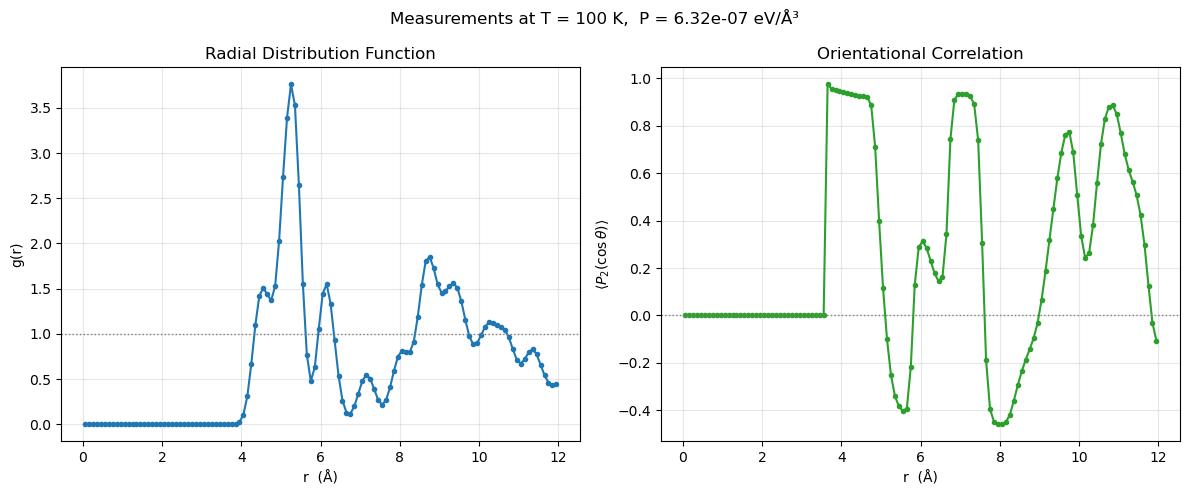

Nematic order:  S = 0.288 ± 0.010  (S_lab = 0.288)
Director:       [ 1.000e+00 -1.087e-03 -8.189e-05]
Enthalpy:       H = -184.887 ± 0.305 eV   (H/N = -0.4622 eV)
Heat capacity:  C_p = 5.277e-04 eV/K/particle  (6.12 k_B/particle)


In [ ]:
# Generate plots for RDF and OCF

rdf = results["rdf"]
ocf = results["ocf"]
nematic = results["nematic"]
H_mean, H_std = results["enthalpy"]
cp = results["heat_capacity"]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Radial distribution function g(r): positional order
axs[0].plot(rdf["r"], rdf["g_r"], marker=".")
axs[0].axhline(1.0, color="gray", ls=":", lw=1)
axs[0].set_xlabel("r  (Å)")
axs[0].set_ylabel("g(r)")
axs[0].set_title("Radial Distribution Function")

# Orientational correlation <P2(cos θ)>(r): neighbour alignment vs separation
axs[1].plot(ocf["r"], ocf["s2_r"], marker=".", color="tab:green")
axs[1].axhline(0.0, color="gray", ls=":", lw=1)
axs[1].set_xlabel("r  (Å)")
axs[1].set_ylabel(r"$\langle P_2(\cos\theta)\rangle$")
axs[1].set_title("Orientational Correlation")

for ax in axs:
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Measurements at T = {temp:g} K,  P = {pressure:.3g} eV/Å³")
fig.tight_layout()

fig.savefig(f"{RUN_DIR}/measurements.png", dpi=150)

plt.show()

# Scalar observables
print(f"Nematic order:  S = {nematic['S']:.3f} ± {nematic['S_std']:.3f}  (S_lab = {nematic['S_lab']:.3f})")
print(f"Director:       {np.array2string(nematic['director'], precision=3)}")
print(f"Enthalpy:       H = {H_mean:.3f} ± {H_std:.3f} eV   (H/N = {H_mean / n_particles:.4f} eV)")
print(f"Heat capacity:  C_p = {cp:.3e} eV/K/particle  ({cp / BOLTZCONST:.2f} k_B/particle)")

In [ ]:
traj = ase.io.read("../results/validation/100.0_6.324209e-07/herringbone_jittered/simulation.xyz", ":")

In [12]:
a = cell_vecs = traj[-1].cell[0] / 4
b = cell_vecs = traj[-1].cell[1] / 4
c = cell_vecs = traj[-1].cell[2] / 2

print(a)
print(b)
print(c)

[8.92786968 0.         0.        ]
[ 0.         10.95693367  0.        ]
[ 0.          0.         12.33701043]
